Aqui o foco foi tratar os dados e preparar as análises descritivas (uni e multivariada)

In [6]:
import pandas as pd

df = pd.read_excel(
    "C:/Users/T-Gamer/Desktop/igor/credit-default-api/data/raw/default_of_credit_card_clients.xls",
    header=1)

print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [7]:
# =====================================================
# Ajuste dos tipos das variáveis
# =====================================================

# Variáveis categóricas nominais
categoricas_nominais = [
    "SEX",
    "MARRIAGE",
    "default payment next month"
]

# Variáveis categóricas ordinais
categoricas_ordinais = [
    "EDUCATION"
]

# Conversão para category
df[categoricas_nominais] = df[categoricas_nominais].astype("category")
df[categoricas_ordinais] = df[categoricas_ordinais].astype("category")

from pandas.api.types import CategoricalDtype

education_order = CategoricalDtype(
    categories=[0, 1, 2, 3, 4, 5, 6],
    ordered=True
)

df["EDUCATION"] = df["EDUCATION"].astype(education_order)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   ID                          30000 non-null  int64   
 1   LIMIT_BAL                   30000 non-null  int64   
 2   SEX                         30000 non-null  category
 3   EDUCATION                   30000 non-null  category
 4   MARRIAGE                    30000 non-null  category
 5   AGE                         30000 non-null  int64   
 6   PAY_0                       30000 non-null  int64   
 7   PAY_2                       30000 non-null  int64   
 8   PAY_3                       30000 non-null  int64   
 9   PAY_4                       30000 non-null  int64   
 10  PAY_5                       30000 non-null  int64   
 11  PAY_6                       30000 non-null  int64   
 12  BILL_AMT1                   30000 non-null  int64   
 13  BILL_AMT2                  

Aqui vamos começar as análises descritivas Univariadas

In [8]:
# Descritivas Gerais

# Quantidade de clientes
n_clientes = df.shape[0]

# Quantidade de variáveis
n_variaveis = df.shape[1]

# Número de inadimplentes
n_inadimplentes = (df["default payment next month"] == 1).sum()

# Número de adimplentes
n_adimplentes = (df["default payment next month"] == 0).sum()

# Percentual de inadimplência
pct_inadimplentes = (
    n_inadimplentes / n_clientes
) * 100

# Memória utilizada
memoria_mb = (
    df.memory_usage(deep=True).sum()
) / (1024 ** 2)

# Tipos das variáveis
tipos_variaveis = df.dtypes.value_counts()

print(f"Quantidade de clientes: {n_clientes:,}")
print(f"Quantidade de variáveis: {n_variaveis}")

print(f"\nClientes adimplentes: {n_adimplentes:,}")
print(f"Clientes inadimplentes: {n_inadimplentes:,}")

print(f"\nPercentual de inadimplência: {pct_inadimplentes:.2f}%")

print(f"\nMemória utilizada: {memoria_mb:.2f} MB")

print("\nTipos das variáveis:")
print(tipos_variaveis)

Quantidade de clientes: 30,000
Quantidade de variáveis: 25

Clientes adimplentes: 23,364
Clientes inadimplentes: 6,636

Percentual de inadimplência: 22.12%

Memória utilizada: 4.92 MB

Tipos das variáveis:
int64       21
category     1
category     1
category     1
category     1
Name: count, dtype: int64


Agora uma análise sobre LIMIT_BAL

ANÁLISE DA VARIÁVEL: LIMIT_BAL
Média: 167,484.32
Mediana: 140,000.00
Desvio padrão: 129,747.66
Mínimo: 10,000.00
Máximo: 1,000,000.00

Quartis
0.25     50000.0
0.50    140000.0
0.75    240000.0
Name: LIMIT_BAL, dtype: float64

Assimetria: 0.993

Quantidade de outliers: 167
Percentual de outliers: 0.56%


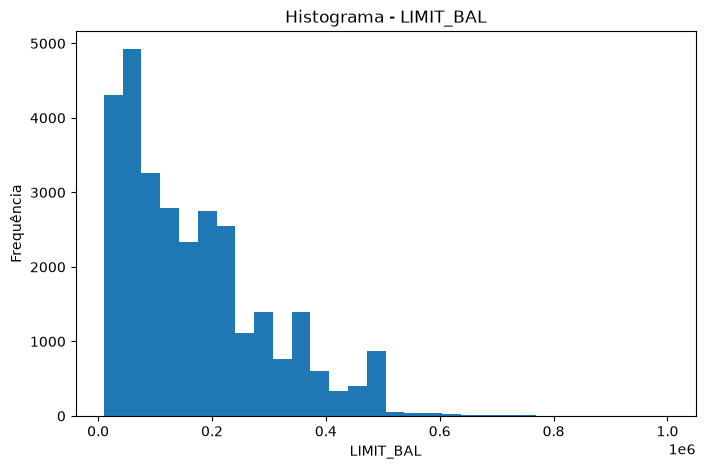

C:\Users\T-Gamer\AppData\Local\Temp\ipykernel_10588\3130842719.py:71: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[variavel], vert=False)


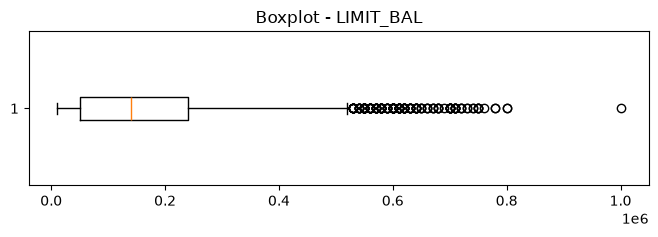

In [12]:
import matplotlib.pyplot as plt

variavel = "LIMIT_BAL"

print("=" * 60)
print(f"ANÁLISE DA VARIÁVEL: {variavel}")
print("=" * 60)

# Estatísticas descritivas
media = df[variavel].mean()
mediana = df[variavel].median()
desvio = df[variavel].std()
minimo = df[variavel].min()
maximo = df[variavel].max()
quartis = df[variavel].quantile([0.25, 0.50, 0.75])

print(f"Média: {media:,.2f}")
print(f"Mediana: {mediana:,.2f}")
print(f"Desvio padrão: {desvio:,.2f}")
print(f"Mínimo: {minimo:,.2f}")
print(f"Máximo: {maximo:,.2f}")

print("\nQuartis")
print(quartis)

# Assimetria
assimetria = df[variavel].skew()

print(f"\nAssimetria: {assimetria:.3f}")

# =====================================================
# Detecção de outliers (Regra do IQR)
# =====================================================

Q1 = quartis.loc[0.25]
Q3 = quartis.loc[0.75]

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df[variavel] < limite_inferior) |
    (df[variavel] > limite_superior)
]

print(f"\nQuantidade de outliers: {len(outliers)}")
print(f"Percentual de outliers: {(len(outliers)/len(df))*100:.2f}%")

# =====================================================
# Histograma
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(df[variavel], bins=30)

plt.title(f"Histograma - {variavel}")
plt.xlabel(variavel)
plt.ylabel("Frequência")

plt.show()

# =====================================================
# Boxplot
# =====================================================

plt.figure(figsize=(8,2))

plt.boxplot(df[variavel], vert=False)

plt.title(f"Boxplot - {variavel}")

plt.show()

In [13]:
df["LIMIT_BAL"].value_counts().sort_index()

LIMIT_BAL
10000       493
16000         2
20000      1976
30000      1610
40000       230
           ... 
750000        4
760000        1
780000        2
800000        2
1000000       1
Name: count, Length: 81, dtype: int64

Agora vamos para a variável AGE

ANÁLISE DA VARIÁVEL: AGE
Média: 35.49
Mediana: 34.00
Desvio padrão: 9.22
Mínimo: 21
Máximo: 79

Quartis
0.25    28.0
0.50    34.0
0.75    41.0
Name: AGE, dtype: float64

Assimetria: 0.732

Quantidade de outliers: 272
Percentual de outliers: 0.91%


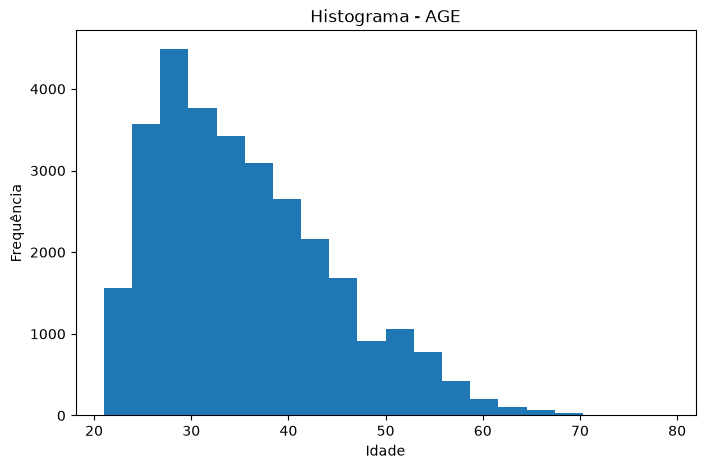

C:\Users\T-Gamer\AppData\Local\Temp\ipykernel_10588\2452720076.py:75: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[variavel], vert=False)


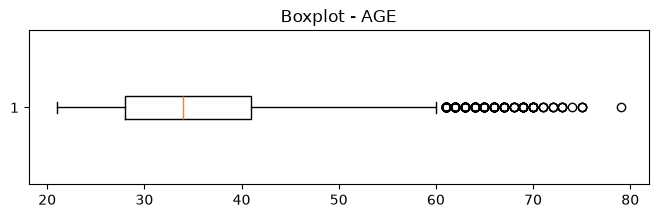

In [14]:
import matplotlib.pyplot as plt

# =====================================================
# Análise univariada - AGE
# =====================================================

variavel = "AGE"

print("=" * 60)
print(f"ANÁLISE DA VARIÁVEL: {variavel}")
print("=" * 60)

# Estatísticas descritivas
media = df[variavel].mean()
mediana = df[variavel].median()
desvio = df[variavel].std()
minimo = df[variavel].min()
maximo = df[variavel].max()
quartis = df[variavel].quantile([0.25, 0.50, 0.75])

print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio padrão: {desvio:.2f}")
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")

print("\nQuartis")
print(quartis)

# Assimetria
assimetria = df[variavel].skew()

print(f"\nAssimetria: {assimetria:.3f}")

# =====================================================
# Outliers
# =====================================================

Q1 = quartis.loc[0.25]
Q3 = quartis.loc[0.75]

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df[variavel] < limite_inferior) |
    (df[variavel] > limite_superior)
]

print(f"\nQuantidade de outliers: {len(outliers)}")
print(f"Percentual de outliers: {(len(outliers)/len(df))*100:.2f}%")

# =====================================================
# Histograma
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(df[variavel], bins=20)

plt.title("Histograma - AGE")
plt.xlabel("Idade")
plt.ylabel("Frequência")

plt.show()

# =====================================================
# Boxplot
# =====================================================

plt.figure(figsize=(8,2))

plt.boxplot(df[variavel], vert=False)

plt.title("Boxplot - AGE")

plt.show()

Análise das variáveis BILL_AMT de 1 até 6

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Variáveis BILL_AMT
# ==========================================

bill_amt = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

resumo = []

for var in bill_amt:

    print("="*60)
    print(var)
    print("="*60)

    media = df[var].mean()
    mediana = df[var].median()
    desvio = df[var].std()
    minimo = df[var].min()
    maximo = df[var].max()
    assimetria = df[var].skew()

    quartis = df[var].quantile([0.25,0.50,0.75])

    print(f"Média: {media:,.2f}")
    print(f"Mediana: {mediana:,.2f}")
    print(f"Desvio padrão: {desvio:,.2f}")
    print(f"Mínimo: {minimo:,.2f}")
    print(f"Máximo: {maximo:,.2f}")

    print("\nQuartis")
    print(quartis)

    print(f"\nAssimetria: {assimetria:.3f}")

    # ------------------------------
    # Outliers
    # ------------------------------

    Q1 = quartis.loc[0.25]
    Q3 = quartis.loc[0.75]

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5*IQR
    limite_superior = Q3 + 1.5*IQR

    outliers = df[
        (df[var] < limite_inferior) |
        (df[var] > limite_superior)
    ]

    qtd_outliers = len(outliers)
    perc_outliers = qtd_outliers/len(df)*100

    print(f"\nOutliers: {qtd_outliers}")
    print(f"Percentual: {perc_outliers:.2f}%")

    resumo.append({
        "Variável": var,
        "Média": media,
        "Mediana": mediana,
        "Desvio Padrão": desvio,
        "Assimetria": assimetria,
        "Outliers": qtd_outliers,
        "% Outliers": perc_outliers
    })

# ==========================================
# Resumo
# ==========================================

resumo = pd.DataFrame(resumo)

print("\n")
print("="*70)
print("RESUMO GERAL")
print("="*70)

display(resumo)

BILL_AMT1
Média: 51,223.33
Mediana: 22,381.50
Desvio padrão: 73,635.86
Mínimo: -165,580.00
Máximo: 964,511.00

Quartis
0.25     3558.75
0.50    22381.50
0.75    67091.00
Name: BILL_AMT1, dtype: float64

Assimetria: 2.664

Outliers: 2400
Percentual: 8.00%
BILL_AMT2
Média: 49,179.08
Mediana: 21,200.00
Desvio padrão: 71,173.77
Mínimo: -69,777.00
Máximo: 983,931.00

Quartis
0.25     2984.75
0.50    21200.00
0.75    64006.25
Name: BILL_AMT2, dtype: float64

Assimetria: 2.705

Outliers: 2395
Percentual: 7.98%
BILL_AMT3
Média: 47,013.15
Mediana: 20,088.50
Desvio padrão: 69,349.39
Mínimo: -157,264.00
Máximo: 1,664,089.00

Quartis
0.25     2666.25
0.50    20088.50
0.75    60164.75
Name: BILL_AMT3, dtype: float64

Assimetria: 3.088

Outliers: 2469
Percentual: 8.23%
BILL_AMT4
Média: 43,262.95
Mediana: 19,052.00
Desvio padrão: 64,332.86
Mínimo: -170,000.00
Máximo: 891,586.00

Quartis
0.25     2326.75
0.50    19052.00
0.75    54506.00
Name: BILL_AMT4, dtype: float64

Assimetria: 2.822

Outliers: 26

,Variável,Média,Mediana,Desvio Padrão,Assimetria,Outliers,% Outliers
0,BILL_AMT1,51223.330900,22381.5,73635.860576,2.663861,2400,8.000000
1,BILL_AMT2,49179.075167,21200.0,71173.768783,2.705221,2395,7.983333
2,BILL_AMT3,47013.154800,20088.5,69349.387427,3.087830,2469,8.230000
3,BILL_AMT4,43262.948967,19052.0,64332.856134,2.821965,2622,8.740000
4,BILL_AMT5,40311.400967,18104.5,60797.155770,2.876380,2725,9.083333
5,BILL_AMT6,38871.760400,17071.0,59554.107537,2.846645,2693,8.976667


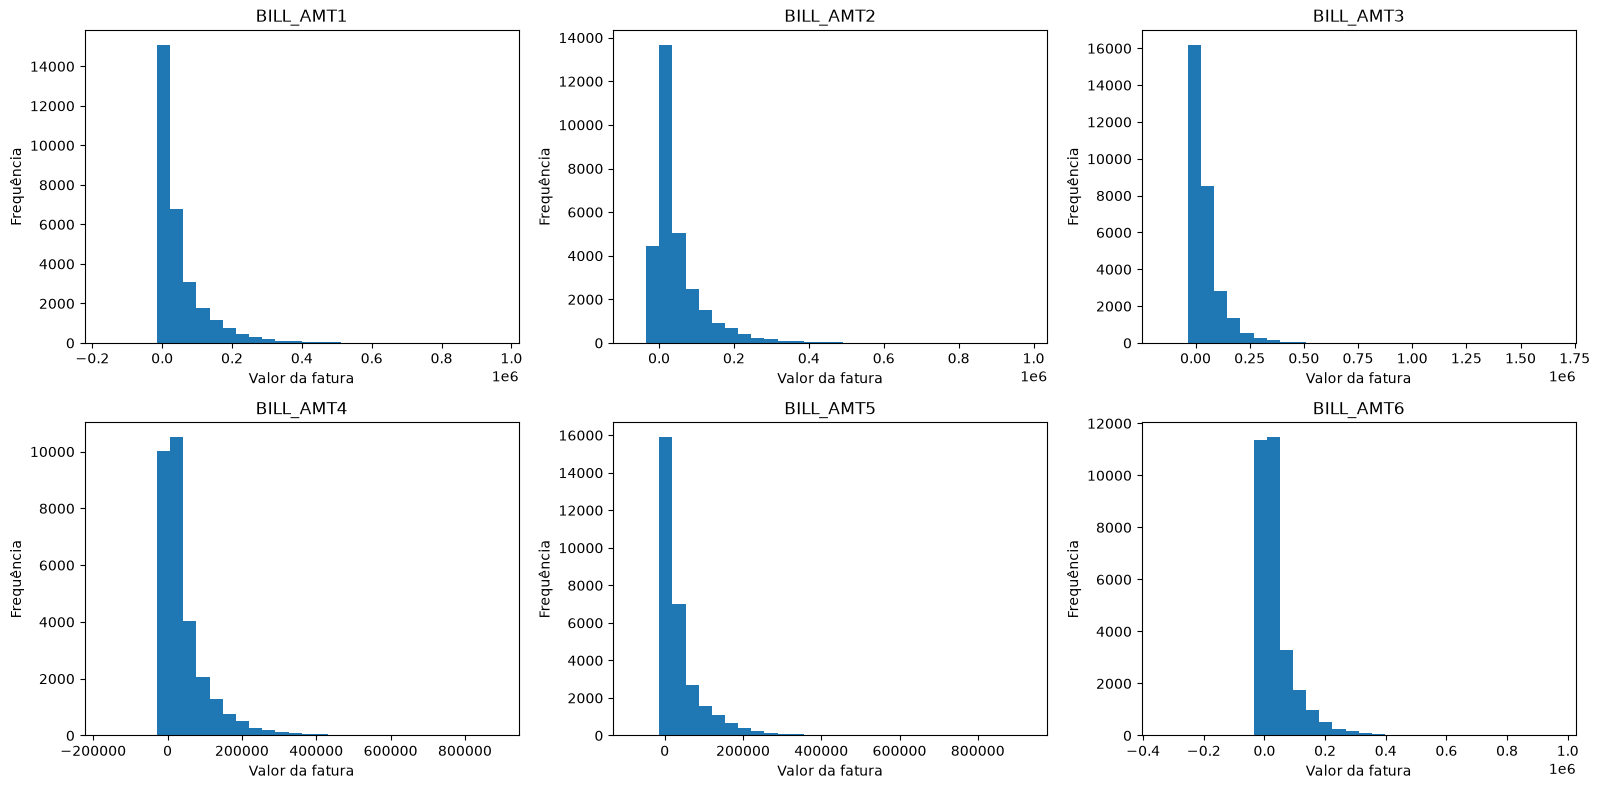

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16,8))

for ax, var in zip(axes.flatten(), bill_amt):

    ax.hist(df[var], bins=30)

    ax.set_title(var)
    ax.set_xlabel("Valor da fatura")
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

Análise de pay1 até pay6

PAY_AMT1
Média: 5,663.58
Mediana: 2,100.00
Desvio padrão: 16,563.28
Mínimo: 0.00
Máximo: 873,552.00

Quartis
0.25    1000.0
0.50    2100.0
0.75    5006.0
Name: PAY_AMT1, dtype: float64

Assimetria: 14.668

Outliers: 2745
Percentual: 9.15%
PAY_AMT2
Média: 5,921.16
Mediana: 2,009.00
Desvio padrão: 23,040.87
Mínimo: 0.00
Máximo: 1,684,259.00

Quartis
0.25     833.0
0.50    2009.0
0.75    5000.0
Name: PAY_AMT2, dtype: float64

Assimetria: 30.454

Outliers: 2714
Percentual: 9.05%
PAY_AMT3
Média: 5,225.68
Mediana: 1,800.00
Desvio padrão: 17,606.96
Mínimo: 0.00
Máximo: 896,040.00

Quartis
0.25     390.0
0.50    1800.0
0.75    4505.0
Name: PAY_AMT3, dtype: float64

Assimetria: 17.217

Outliers: 2598
Percentual: 8.66%
PAY_AMT4
Média: 4,826.08
Mediana: 1,500.00
Desvio padrão: 15,666.16
Mínimo: 0.00
Máximo: 621,000.00

Quartis
0.25     296.00
0.50    1500.00
0.75    4013.25
Name: PAY_AMT4, dtype: float64

Assimetria: 12.905

Outliers: 2994
Percentual: 9.98%
PAY_AMT5
Média: 4,799.39
Mediana: 1,500

,Variável,Média,Mediana,Desvio Padrão,Assimetria,Outliers,% Outliers
0,PAY_AMT1,5663.580500,2100.0,16563.280354,14.668364,2745,9.150000
1,PAY_AMT2,5921.163500,2009.0,23040.870402,30.453817,2714,9.046667
2,PAY_AMT3,5225.681500,1800.0,17606.961470,17.216635,2598,8.660000
3,PAY_AMT4,4826.076867,1500.0,15666.159744,12.904985,2994,9.980000
4,PAY_AMT5,4799.387633,1500.0,15278.305679,11.127417,2945,9.816667
5,PAY_AMT6,5215.502567,1500.0,17777.465775,10.640727,2958,9.860000


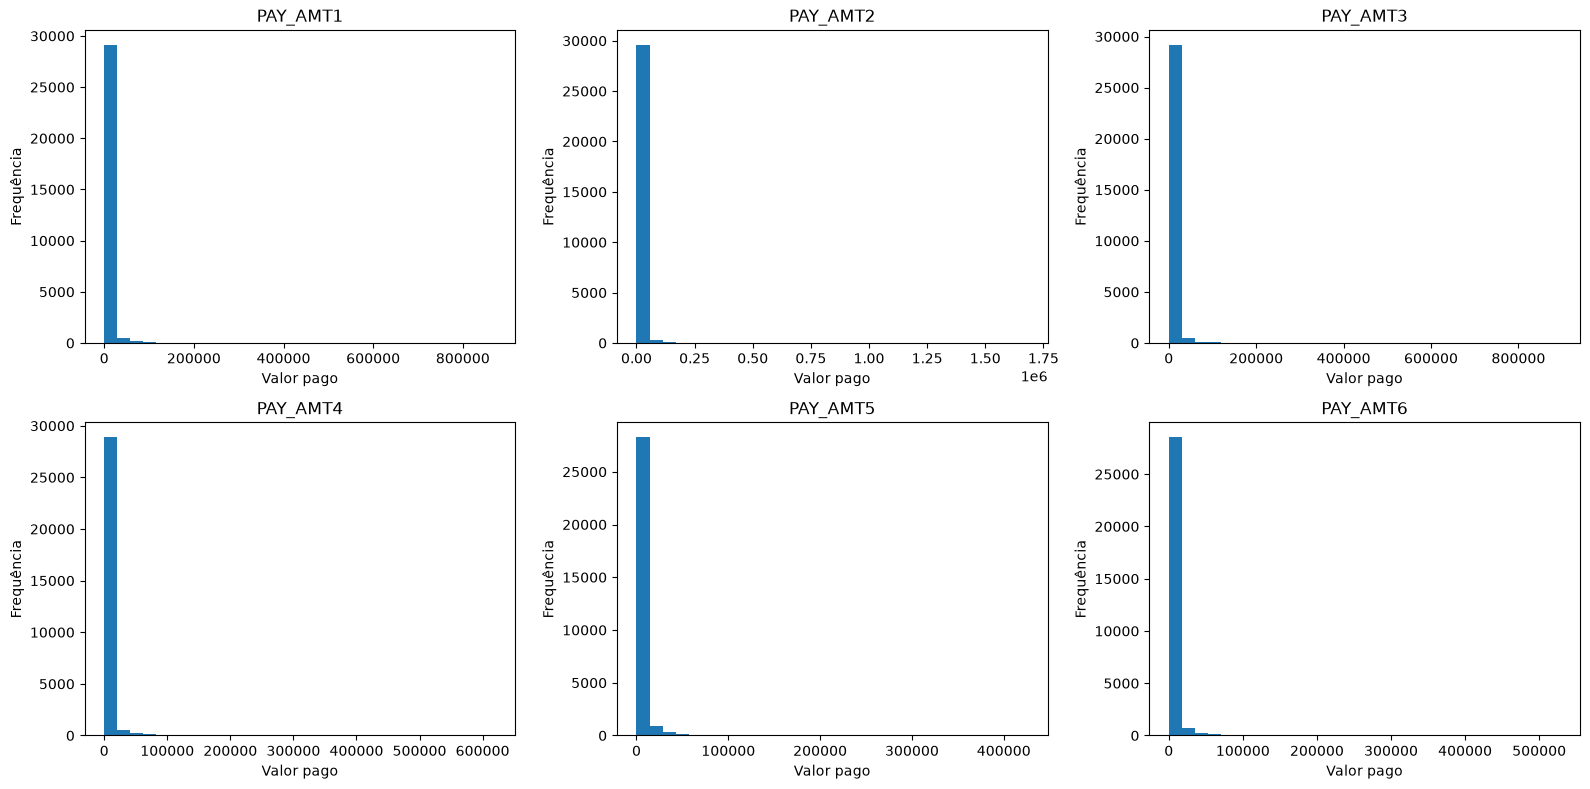

C:\Users\T-Gamer\AppData\Local\Temp\ipykernel_10588\2209768537.py:108: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[var], vert=False)
C:\Users\T-Gamer\AppData\Local\Temp\ipykernel_10588\2209768537.py:108: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[var], vert=False)
C:\Users\T-Gamer\AppData\Local\Temp\ipykernel_10588\2209768537.py:108: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[var], vert=False)
C:\Users\T-Gamer\AppData\Local\Temp\ipykernel_10588\2209768537.py:108: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizont

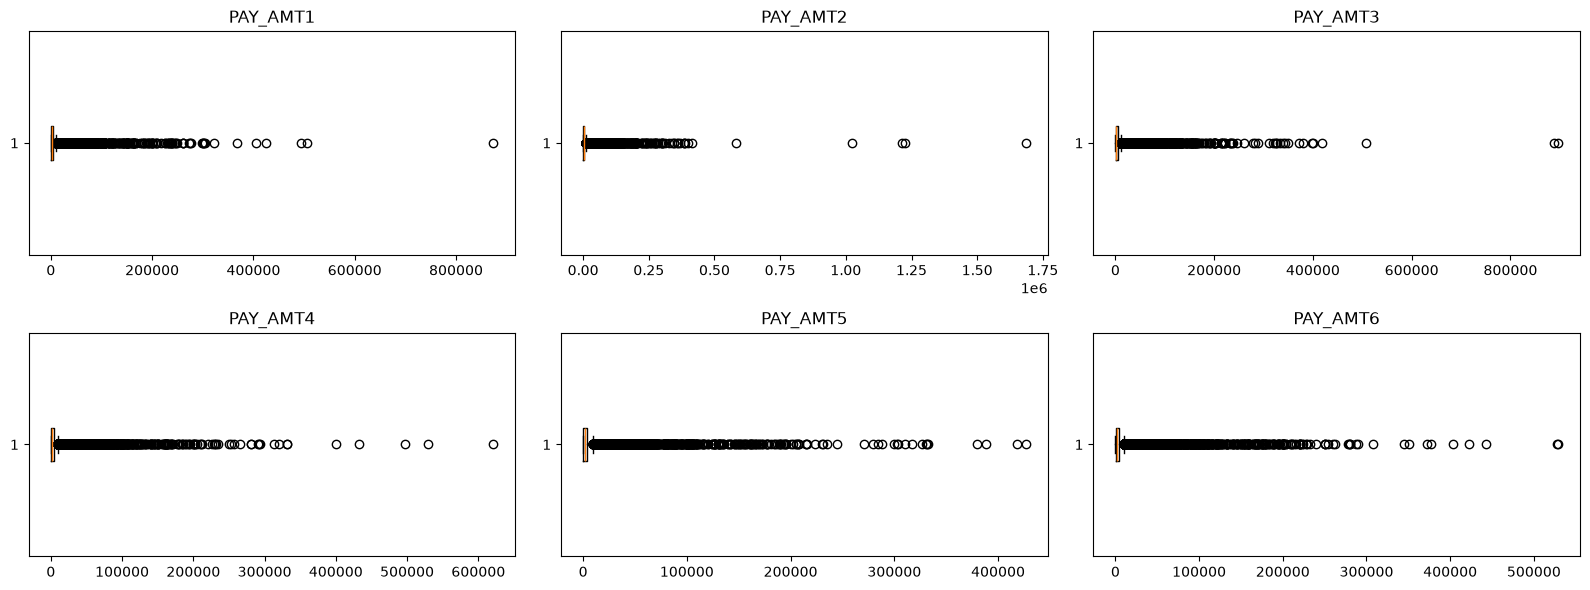

C:\Users\T-Gamer\AppData\Local\Temp\ipykernel_10588\2209768537.py:117: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


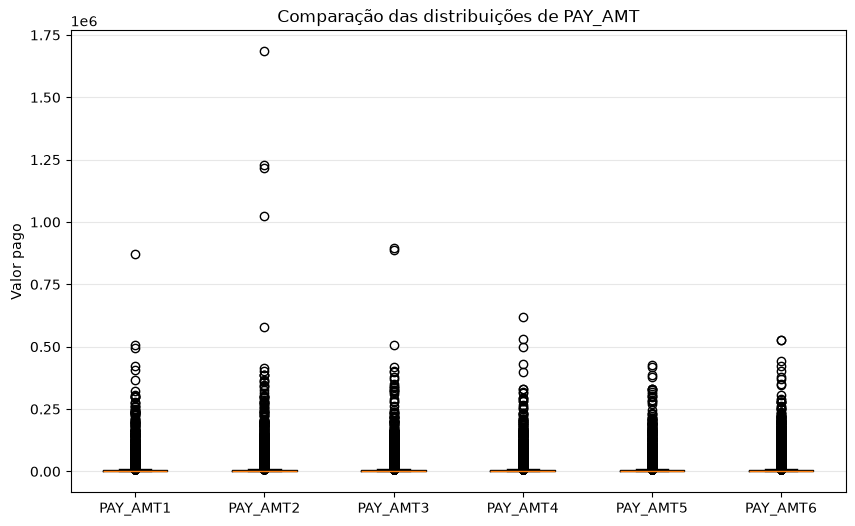

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Variáveis PAY_AMT
# ==========================================

pay_amt = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

resumo = []

for var in pay_amt:

    print("="*60)
    print(var)
    print("="*60)

    media = df[var].mean()
    mediana = df[var].median()
    desvio = df[var].std()
    minimo = df[var].min()
    maximo = df[var].max()
    assimetria = df[var].skew()

    quartis = df[var].quantile([0.25, 0.50, 0.75])

    print(f"Média: {media:,.2f}")
    print(f"Mediana: {mediana:,.2f}")
    print(f"Desvio padrão: {desvio:,.2f}")
    print(f"Mínimo: {minimo:,.2f}")
    print(f"Máximo: {maximo:,.2f}")

    print("\nQuartis")
    print(quartis)

    print(f"\nAssimetria: {assimetria:.3f}")

    # ==========================================
    # Outliers
    # ==========================================

    Q1 = quartis.loc[0.25]
    Q3 = quartis.loc[0.75]

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[var] < limite_inferior) |
        (df[var] > limite_superior)
    ]

    qtd_outliers = len(outliers)
    perc_outliers = qtd_outliers / len(df) * 100

    print(f"\nOutliers: {qtd_outliers}")
    print(f"Percentual: {perc_outliers:.2f}%")

    resumo.append({
        "Variável": var,
        "Média": media,
        "Mediana": mediana,
        "Desvio Padrão": desvio,
        "Assimetria": assimetria,
        "Outliers": qtd_outliers,
        "% Outliers": perc_outliers
    })

# ==========================================
# Resumo Geral
# ==========================================

resumo = pd.DataFrame(resumo)

print("\n")
print("="*70)
print("RESUMO GERAL")
print("="*70)

display(resumo)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, var in zip(axes.flatten(), pay_amt):

    ax.hist(df[var], bins=30)

    ax.set_title(var)
    ax.set_xlabel("Valor pago")
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 6))

for ax, var in zip(axes.flatten(), pay_amt):

    ax.boxplot(df[var], vert=False)

    ax.set_title(var)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))

plt.boxplot(
    [df[var] for var in pay_amt],
    tick_labels=pay_amt,
    vert=True
)

plt.title("Comparação das distribuições de PAY_AMT")
plt.ylabel("Valor pago")

plt.grid(axis="y", alpha=0.3)

plt.show()

Variáveis Categóricas

ANÁLISE DA VARIÁVEL: SEX

Frequência absoluta
SEX
1    11888
2    18112
Name: count, dtype: int64

Frequência relativa (%)
SEX
1    39.63
2    60.37
Name: proportion, dtype: float64

Valores ausentes:
0

Categorias presentes:
Index([1, 2], dtype='int64')


,Frequência,Percentual (%)
SEX,,
1,11888,39.63
2,18112,60.37


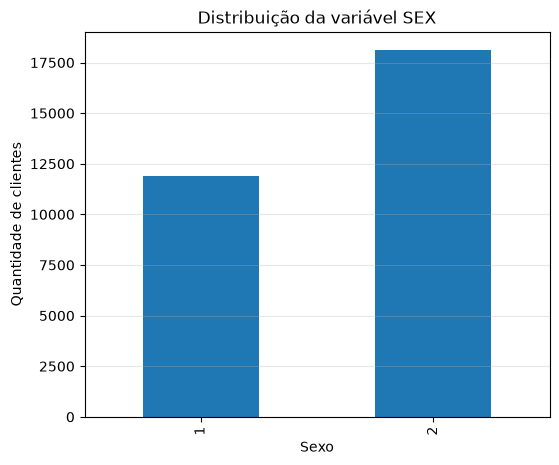

In [21]:
import matplotlib.pyplot as plt

variavel = "SEX"

print("="*60)
print(f"ANÁLISE DA VARIÁVEL: {variavel}")
print("="*60)

# =====================================================
# Frequência absoluta
# =====================================================

freq_abs = df[variavel].value_counts().sort_index()

print("\nFrequência absoluta")
print(freq_abs)

# =====================================================
# Frequência relativa
# =====================================================

freq_rel = (
    df[variavel]
    .value_counts(normalize=True)
    .sort_index()
    *100
)

print("\nFrequência relativa (%)")
print(freq_rel.round(2))

# =====================================================
# Valores ausentes
# =====================================================

print("\nValores ausentes:")
print(df[variavel].isna().sum())

# =====================================================
# Categorias existentes
# =====================================================

print("\nCategorias presentes:")
print(df[variavel].cat.categories)

# =====================================================
# Tabela resumo
# =====================================================

resumo = pd.DataFrame({
    "Frequência": freq_abs,
    "Percentual (%)": freq_rel.round(2)
})

display(resumo)

plt.figure(figsize=(6,5))

freq_abs.plot(kind="bar")

plt.title("Distribuição da variável SEX")
plt.xlabel("Sexo")
plt.ylabel("Quantidade de clientes")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [22]:
import matplotlib.pyplot as plt

variavel = "EDUCATION"

print("="*60)
print(f"ANÁLISE DA VARIÁVEL: {variavel}")
print("="*60)

# ==========================================
# Frequência absoluta
# ==========================================

freq_abs = df[variavel].value_counts().sort_index()

print("\nFrequência absoluta")
print(freq_abs)

# ==========================================
# Frequência relativa
# ==========================================

freq_rel = (
    df[variavel]
    .value_counts(normalize=True)
    .sort_index()
    *100
)

print("\nFrequência relativa (%)")
print(freq_rel.round(2))

# ==========================================
# Valores ausentes
# ==========================================

print("\nValores ausentes:")
print(df[variavel].isna().sum())

# ==========================================
# Categorias presentes
# ==========================================

print("\nCategorias presentes:")
print(df[variavel].cat.categories)

# ==========================================
# Tabela resumo
# ==========================================

resumo = pd.DataFrame({
    "Frequência": freq_abs,
    "Percentual (%)": freq_rel.round(2)
})

display(resumo)

ANÁLISE DA VARIÁVEL: EDUCATION

Frequência absoluta
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Frequência relativa (%)
EDUCATION
0     0.05
1    35.28
2    46.77
3    16.39
4     0.41
5     0.93
6     0.17
Name: proportion, dtype: float64

Valores ausentes:
0

Categorias presentes:
Index([0, 1, 2, 3, 4, 5, 6], dtype='int64')


,Frequência,Percentual (%)
EDUCATION,,
0,14,0.05
1,10585,35.28
2,14030,46.77
3,4917,16.39
4,123,0.41
5,280,0.93
6,51,0.17


In [23]:
import matplotlib.pyplot as plt

variavel = "MARRIAGE"

print("="*60)
print(f"ANÁLISE DA VARIÁVEL: {variavel}")
print("="*60)

# ==========================================
# Frequência absoluta
# ==========================================

freq_abs = df[variavel].value_counts().sort_index()

print("\nFrequência absoluta")
print(freq_abs)

# ==========================================
# Frequência relativa
# ==========================================

freq_rel = (
    df[variavel]
    .value_counts(normalize=True)
    .sort_index()
    *100
)

print("\nFrequência relativa (%)")
print(freq_rel.round(2))

# ==========================================
# Valores ausentes
# ==========================================

print("\nValores ausentes:")
print(df[variavel].isna().sum())

# ==========================================
# Categorias presentes
# ==========================================

print("\nCategorias presentes:")
print(df[variavel].cat.categories)

# ==========================================
# Tabela resumo
# ==========================================

resumo = pd.DataFrame({
    "Frequência": freq_abs,
    "Percentual (%)": freq_rel.round(2)
})

display(resumo)

ANÁLISE DA VARIÁVEL: MARRIAGE

Frequência absoluta
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Frequência relativa (%)
MARRIAGE
0     0.18
1    45.53
2    53.21
3     1.08
Name: proportion, dtype: float64

Valores ausentes:
0

Categorias presentes:
Index([0, 1, 2, 3], dtype='int64')


,Frequência,Percentual (%)
MARRIAGE,,
0,54,0.18
1,13659,45.53
2,15964,53.21
3,323,1.08


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# Variáveis PAY
# ==========================================

pay = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

resumo = []

for var in pay:

    print("="*60)
    print(f"ANÁLISE DA VARIÁVEL: {var}")
    print("="*60)

    # Frequência absoluta
    freq_abs = df[var].value_counts().sort_index()

    print("\nFrequência absoluta")
    print(freq_abs)

    # Frequência relativa
    freq_rel = (
        df[var]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print("\nFrequência relativa (%)")
    print(freq_rel.round(2))

    # Valores ausentes
    print("\nValores ausentes:")
    print(df[var].isna().sum())

    # Categorias presentes
    print("\nCategorias presentes:")

    print(sorted(df[var].unique()))

    # Armazena resultados
    temp = pd.DataFrame({
        "Variável": var,
        "Categoria": freq_abs.index,
        "Frequência": freq_abs.values,
        "Percentual (%)": freq_rel.values
    })

    resumo.append(temp)

# ==========================================
# Resumo Geral
# ==========================================

resumo = pd.concat(resumo, ignore_index=True)

display(resumo)

ANÁLISE DA VARIÁVEL: PAY_0

Frequência absoluta
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

Frequência relativa (%)
PAY_0
-2     9.20
-1    18.95
 0    49.12
 1    12.29
 2     8.89
 3     1.07
 4     0.25
 5     0.09
 6     0.04
 7     0.03
 8     0.06
Name: proportion, dtype: float64

Valores ausentes:
0

Categorias presentes:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
ANÁLISE DA VARIÁVEL: PAY_2

Frequência absoluta
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

Frequência relativa (%)
PAY_2
-2    12.61
-1    20.17
 0    52.43
 1     0.09
 2    13.09
 3     1.09
 4     0.33
 5     0.08
 6     0.04
 7     0.07
 8     0.00
Name: proportion, dtype: fl

,Variável,Categoria,Frequência,Percentual (%)
0,PAY_0,-2,2759,9.196667
1,PAY_0,-1,5686,18.953333
2,PAY_0,0,14737,49.123333
3,PAY_0,1,3688,12.293333
4,PAY_0,2,2667,8.890000
...,...,...,...,...
59,PAY_6,4,49,0.163333
60,PAY_6,5,13,0.043333
61,PAY_6,6,19,0.063333
62,PAY_6,7,46,0.153333


Avaliando relação entre as variáveis independente

In [29]:
import pandas as pd
import numpy as np

# Variáveis numéricas
numericas = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6",
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"
]

correlacao = df[numericas].corr(method="pearson")

print("="*60)
print("MATRIZ DE CORRELAÇÃO")
print("="*60)

print(correlacao.round(3))

MATRIZ DE CORRELAÇÃO
           LIMIT_BAL    AGE  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  \
LIMIT_BAL      1.000  0.145      0.285      0.278      0.283      0.294   
AGE            0.145  1.000      0.056      0.054      0.054      0.051   
BILL_AMT1      0.285  0.056      1.000      0.951      0.892      0.860   
BILL_AMT2      0.278  0.054      0.951      1.000      0.928      0.892   
BILL_AMT3      0.283  0.054      0.892      0.928      1.000      0.924   
BILL_AMT4      0.294  0.051      0.860      0.892      0.924      1.000   
BILL_AMT5      0.296  0.049      0.830      0.860      0.884      0.940   
BILL_AMT6      0.290  0.048      0.803      0.832      0.853      0.901   
PAY_AMT1       0.195  0.026      0.140      0.280      0.244      0.233   
PAY_AMT2       0.178  0.022      0.099      0.101      0.317      0.208   
PAY_AMT3       0.210  0.029      0.157      0.151      0.130      0.300   
PAY_AMT4       0.203  0.021      0.158      0.147      0.143      0.130   
PAY_

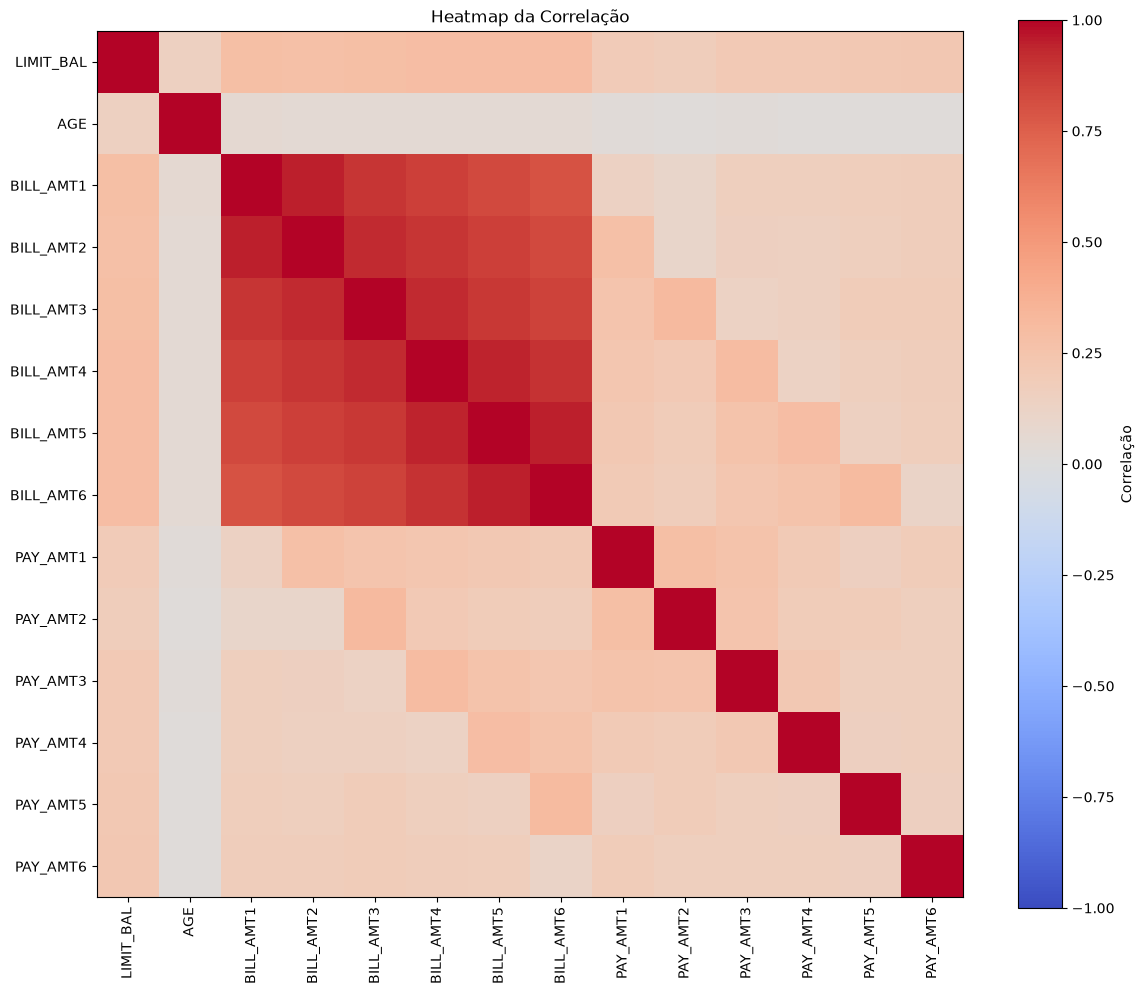

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.imshow(correlacao, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlação")

plt.xticks(range(len(correlacao.columns)),
           correlacao.columns,
           rotation=90)

plt.yticks(range(len(correlacao.columns)),
           correlacao.columns)

plt.title("Heatmap da Correlação")

plt.tight_layout()

plt.show()

In [38]:
from scipy.stats import chi2_contingency
import numpy as np

categoricas = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]


def cramers_v(x, y):

    tabela = pd.crosstab(x, y)

    chi2 = chi2_contingency(tabela)[0]

    n = tabela.sum().sum()

    phi2 = chi2 / n

    r, k = tabela.shape

    return np.sqrt(phi2 / min(k-1, r-1))

resultado = []

for i in range(len(categoricas)):
    for j in range(i+1, len(categoricas)):

        var1 = categoricas[i]
        var2 = categoricas[j]

        v = cramers_v(df[var1], df[var2])

        resultado.append({
            "Variável 1": var1,
            "Variável 2": var2,
            "Cramer's V": round(v,3)
        })

resultado = pd.DataFrame(resultado)

resultado = resultado.sort_values(
    by="Cramer's V",
    ascending=False
)

print(resultado)

   Variável 1 Variável 2  Cramer's V
21      PAY_0      PAY_2       0.662
33      PAY_4      PAY_5       0.656
35      PAY_5      PAY_6       0.650
26      PAY_2      PAY_3       0.627
30      PAY_3      PAY_4       0.620
34      PAY_4      PAY_6       0.550
22      PAY_0      PAY_3       0.520
31      PAY_3      PAY_5       0.512
27      PAY_2      PAY_4       0.482
32      PAY_3      PAY_6       0.437
23      PAY_0      PAY_4       0.417
28      PAY_2      PAY_5       0.386
24      PAY_0      PAY_5       0.358
29      PAY_2      PAY_6       0.333
25      PAY_0      PAY_6       0.314
8   EDUCATION   MARRIAGE       0.115
10  EDUCATION      PAY_2       0.090
11  EDUCATION      PAY_3       0.087
9   EDUCATION      PAY_0       0.083
12  EDUCATION      PAY_4       0.080
3         SEX      PAY_2       0.077
4         SEX      PAY_3       0.073
13  EDUCATION      PAY_5       0.073
14  EDUCATION      PAY_6       0.071
2         SEX      PAY_0       0.068
5         SEX      PAY_4       0.067
6

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[numericas].copy()

vif = pd.DataFrame()

vif["Variável"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values(
    by="VIF",
    ascending=False
)

print(vif)

     Variável        VIF
3   BILL_AMT2  38.058414
6   BILL_AMT5  35.826768
4   BILL_AMT3  31.712525
5   BILL_AMT4  29.402979
7   BILL_AMT6  21.286025
2   BILL_AMT1  20.646093
0   LIMIT_BAL   3.214685
1         AGE   2.741991
9    PAY_AMT2   2.369543
8    PAY_AMT1   1.888997
10   PAY_AMT3   1.887750
12   PAY_AMT5   1.844508
11   PAY_AMT4   1.783987
13   PAY_AMT6   1.269605


In [39]:
print("="*60)
print("INTERPRETAÇÃO DO VIF")
print("="*60)

for _, row in vif.iterrows():

    valor = row["VIF"]

    if valor < 5:
        texto = "Sem indícios de multicolinearidade."

    elif valor < 10:
        texto = "Multicolinearidade moderada."

    else:
        texto = "Alta multicolinearidade."

    print(f"{row['Variável']}: VIF = {valor:.2f} -> {texto}")

INTERPRETAÇÃO DO VIF
BILL_AMT2: VIF = 38.06 -> Alta multicolinearidade.
BILL_AMT5: VIF = 35.83 -> Alta multicolinearidade.
BILL_AMT3: VIF = 31.71 -> Alta multicolinearidade.
BILL_AMT4: VIF = 29.40 -> Alta multicolinearidade.
BILL_AMT6: VIF = 21.29 -> Alta multicolinearidade.
BILL_AMT1: VIF = 20.65 -> Alta multicolinearidade.
LIMIT_BAL: VIF = 3.21 -> Sem indícios de multicolinearidade.
AGE: VIF = 2.74 -> Sem indícios de multicolinearidade.
PAY_AMT2: VIF = 2.37 -> Sem indícios de multicolinearidade.
PAY_AMT1: VIF = 1.89 -> Sem indícios de multicolinearidade.
PAY_AMT3: VIF = 1.89 -> Sem indícios de multicolinearidade.
PAY_AMT5: VIF = 1.84 -> Sem indícios de multicolinearidade.
PAY_AMT4: VIF = 1.78 -> Sem indícios de multicolinearidade.
PAY_AMT6: VIF = 1.27 -> Sem indícios de multicolinearidade.


Relação da variável dependente com as independentes

VARIÁVEL RESPOSTA
                            Frequência  Percentual (%)
default payment next month                            
0                                23364           77.88
1                                 6636           22.12


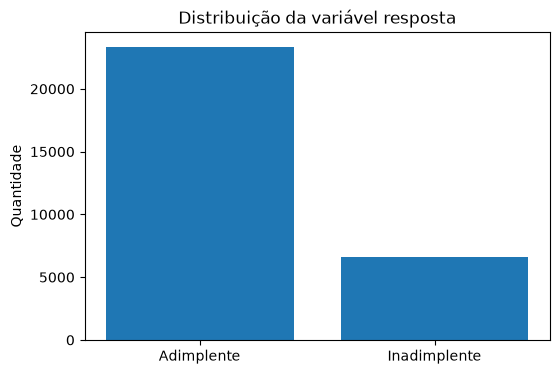

LIMIT_BAL
                                     mean       50%            std      min  \
default payment next month                                                    
0                           178099.726074  150000.0  131628.359660  10000.0   
1                           130109.656420   90000.0  115378.540571  10000.0   

                                  max  
default payment next month             
0                           1000000.0  
1                            740000.0  


<Figure size 600x400 with 0 Axes>

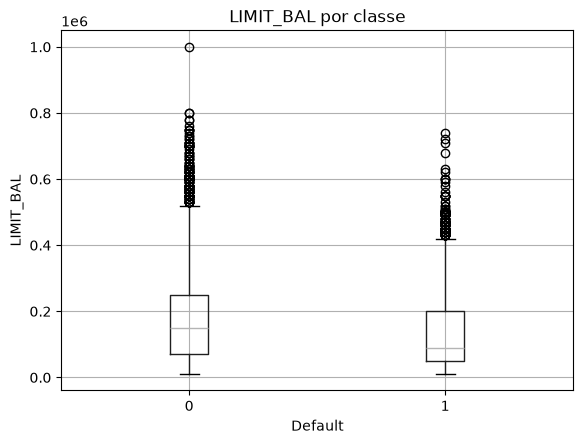

AGE
                                 mean   50%       std   min   max
default payment next month                                       
0                           35.417266  34.0  9.077355  21.0  79.0
1                           35.725738  34.0  9.693438  21.0  75.0


<Figure size 600x400 with 0 Axes>

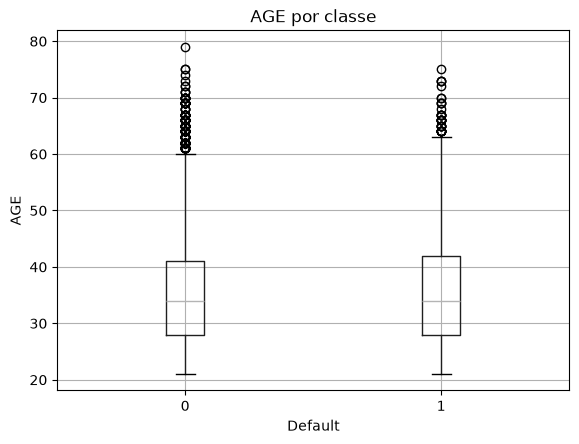

BILL_AMT1
                                    mean      50%           std       min  \
default payment next month                                                  
0                           51994.227273  23119.5  73577.606694 -165580.0   
1                           48509.162297  20185.0  73782.067220   -6676.0   

                                 max  
default payment next month            
0                           964511.0  
1                           613860.0  


<Figure size 600x400 with 0 Axes>

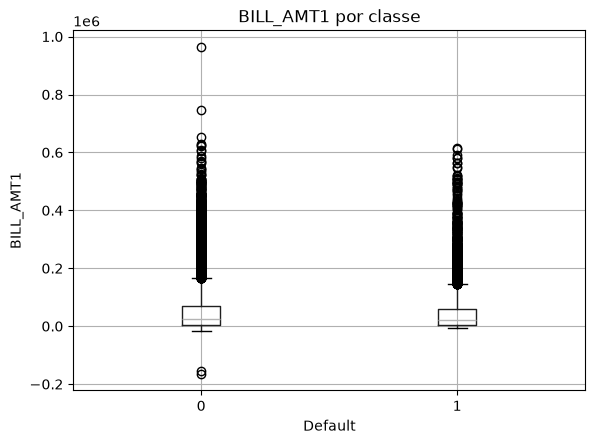

BILL_AMT2
                                    mean      50%           std      min  \
default payment next month                                                 
0                           49717.435670  21660.5  71029.946709 -69777.0   
1                           47283.617842  20300.5  71651.030364 -17710.0   

                                 max  
default payment next month            
0                           983931.0  
1                           581775.0  


<Figure size 600x400 with 0 Axes>

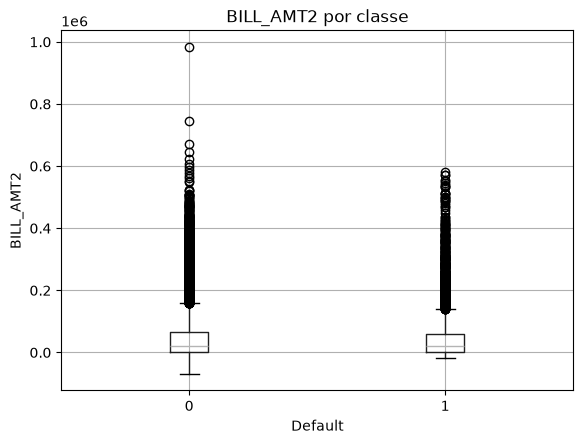

BILL_AMT3
                                    mean      50%           std       min  \
default payment next month                                                  
0                           47533.365605  20202.5  69576.661008 -157264.0   
1                           45181.598855  19834.5  68516.975738  -61506.0   

                                  max  
default payment next month             
0                           1664089.0  
1                            578971.0  


<Figure size 600x400 with 0 Axes>

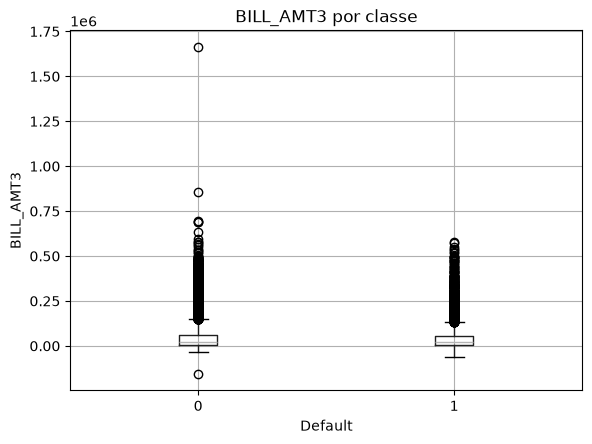

BILL_AMT4
                                    mean      50%           std       min  \
default payment next month                                                  
0                           43611.165254  19000.0  64324.796730 -170000.0   
1                           42036.950573  19119.5  64351.076092  -65167.0   

                                 max  
default payment next month            
0                           891586.0  
1                           548020.0  


<Figure size 600x400 with 0 Axes>

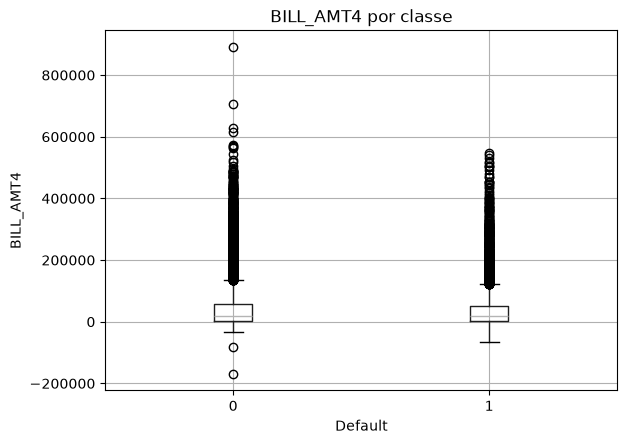

BILL_AMT5
                                    mean      50%           std      min  \
default payment next month                                                 
0                           40530.445343  17998.0  60617.268112 -81334.0   
1                           39540.190476  18478.5  61424.695949 -53007.0   

                                 max  
default payment next month            
0                           927171.0  
1                           547880.0  


<Figure size 600x400 with 0 Axes>

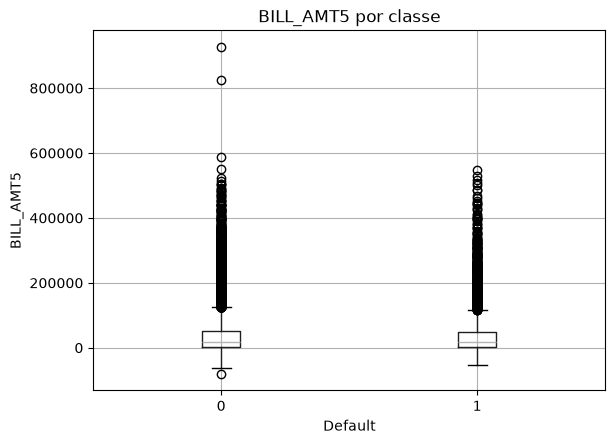

BILL_AMT6
                                    mean      50%           std       min  \
default payment next month                                                  
0                           39042.268704  16679.0  59547.015717 -209051.0   
1                           38271.435503  18028.5  59579.674268 -339603.0   

                                 max  
default payment next month            
0                           961664.0  
1                           514975.0  


<Figure size 600x400 with 0 Axes>

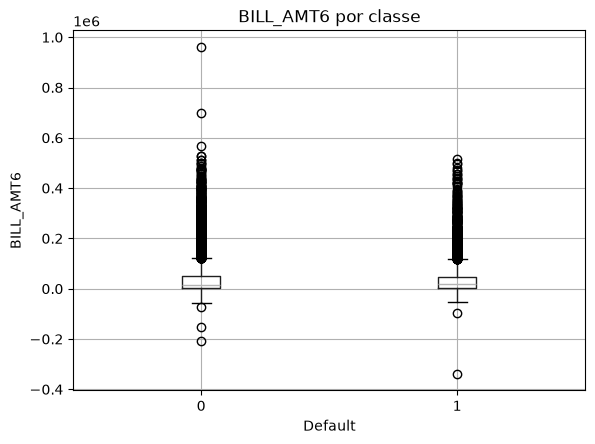

PAY_AMT1
                                   mean     50%           std  min       max
default payment next month                                                  
0                           6307.337357  2459.5  18014.508990  0.0  873552.0
1                           3397.044153  1636.0   9544.252427  0.0  300000.0


<Figure size 600x400 with 0 Axes>

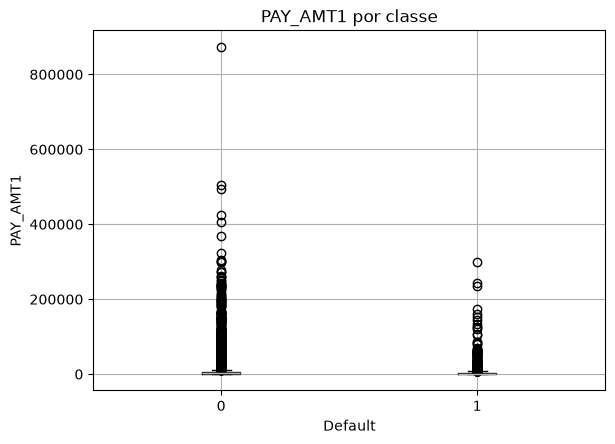

PAY_AMT2
                                   mean     50%           std  min        max
default payment next month                                                   
0                           6640.465074  2247.5  25302.263601  0.0  1684259.0
1                           3388.649638  1533.5  11737.986064  0.0   358689.0


<Figure size 600x400 with 0 Axes>

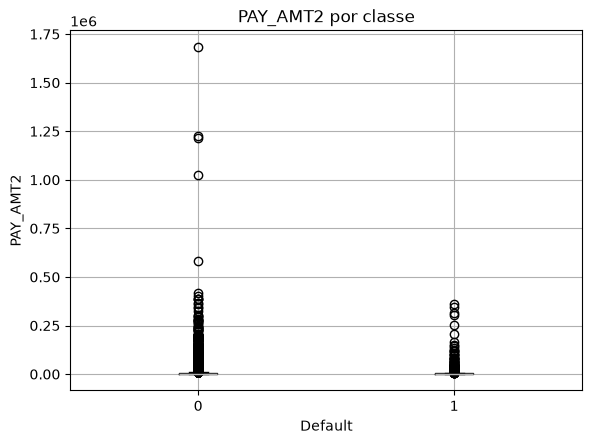

PAY_AMT3
                                   mean     50%           std  min       max
default payment next month                                                  
0                           5753.496833  2000.0  18684.255937  0.0  896040.0
1                           3367.351567  1222.0  12959.624486  0.0  508229.0


<Figure size 600x400 with 0 Axes>

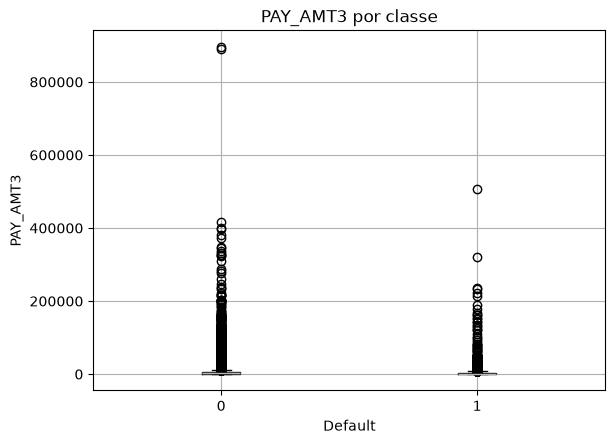

PAY_AMT4
                                   mean     50%           std  min       max
default payment next month                                                  
0                           5300.529319  1734.0  16689.778060  0.0  621000.0
1                           3155.626733  1000.0  11191.973162  0.0  432130.0


<Figure size 600x400 with 0 Axes>

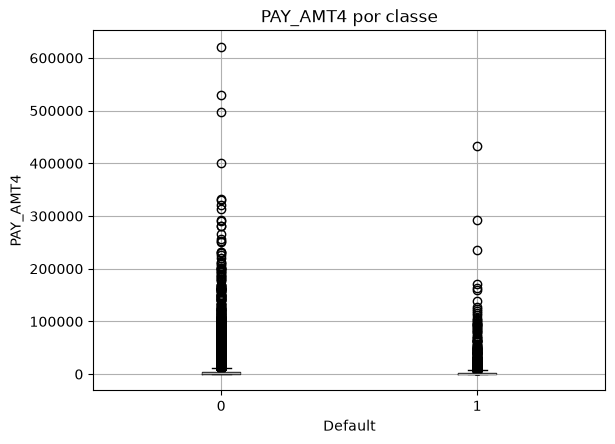

PAY_AMT5
                                   mean     50%           std  min       max
default payment next month                                                  
0                           5248.220296  1765.0  16071.667860  0.0  426529.0
1                           3219.139542  1000.0  11944.731175  0.0  332000.0


<Figure size 600x400 with 0 Axes>

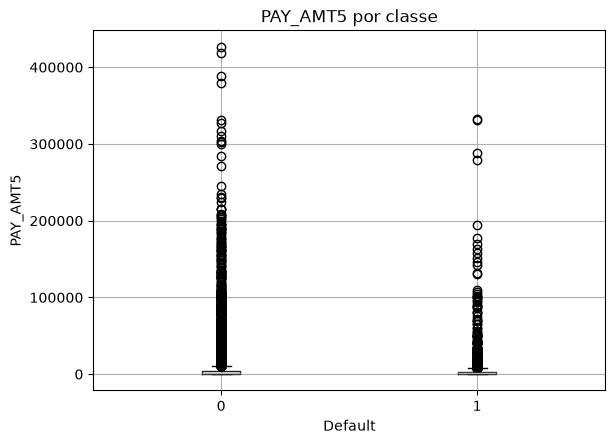

PAY_AMT6
                                   mean     50%           std  min       max
default payment next month                                                  
0                           5719.371769  1706.0  18792.950473  0.0  528666.0
1                           3441.482068  1000.0  13464.005894  0.0  345293.0


<Figure size 600x400 with 0 Axes>

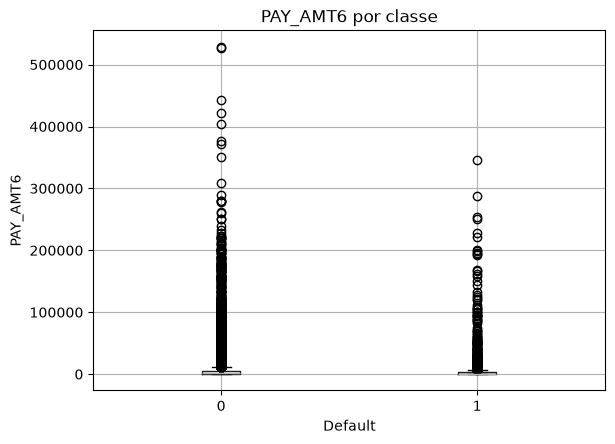

SEX
default payment next month      0      1
SEX                                     
1                           75.83  24.17
2                           79.22  20.78


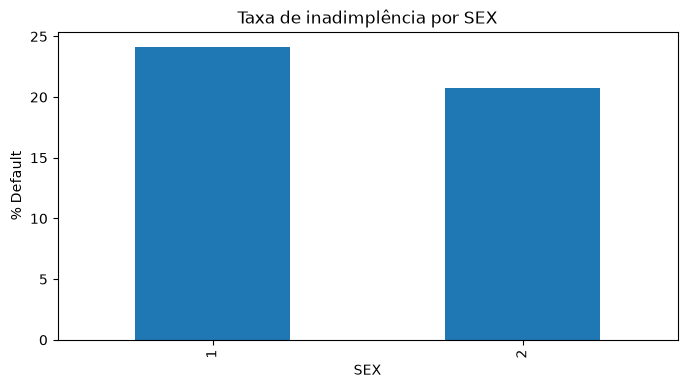

EDUCATION
default payment next month       0      1
EDUCATION                                
0                           100.00   0.00
1                            80.77  19.23
2                            76.27  23.73
3                            74.84  25.16
4                            94.31   5.69
5                            93.57   6.43
6                            84.31  15.69


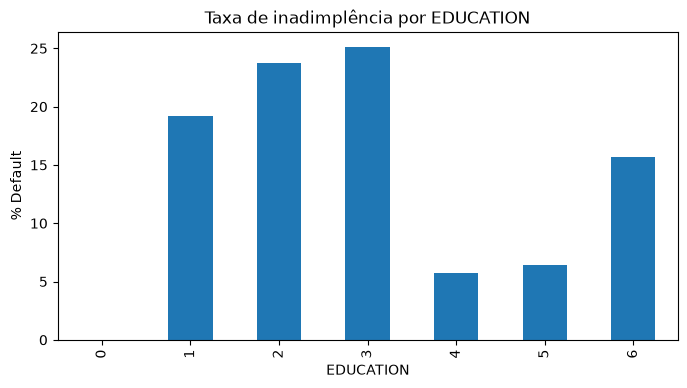

MARRIAGE
default payment next month      0      1
MARRIAGE                                
0                           90.74   9.26
1                           76.53  23.47
2                           79.07  20.93
3                           73.99  26.01


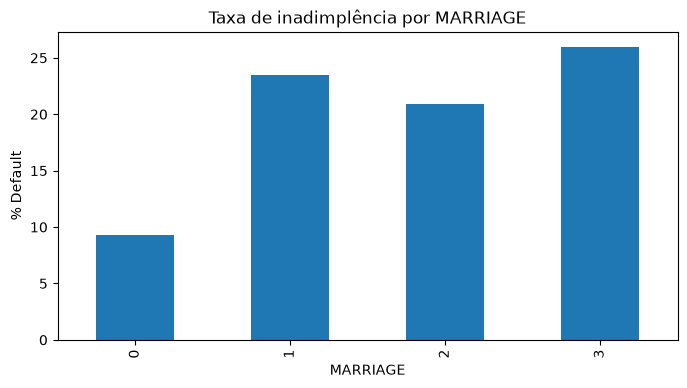

PAY_0
default payment next month      0      1
PAY_0                                   
-2                          86.77  13.23
-1                          83.22  16.78
 0                          87.19  12.81
 1                          66.05  33.95
 2                          30.86  69.14
 3                          24.22  75.78
 4                          31.58  68.42
 5                          50.00  50.00
 6                          45.45  54.55
 7                          22.22  77.78
 8                          42.11  57.89


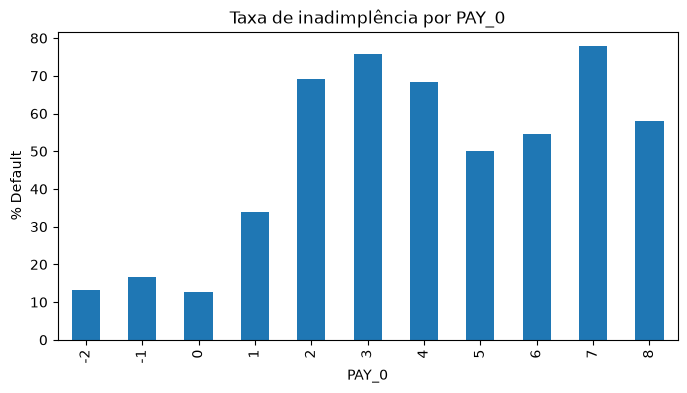

PAY_2
default payment next month       0      1
PAY_2                                    
-2                           81.73  18.27
-1                           84.03  15.97
 0                           84.09  15.91
 1                           82.14  17.86
 2                           44.39  55.61
 3                           38.34  61.66
 4                           49.49  50.51
 5                           40.00  60.00
 6                           25.00  75.00
 7                           40.00  60.00
 8                          100.00   0.00


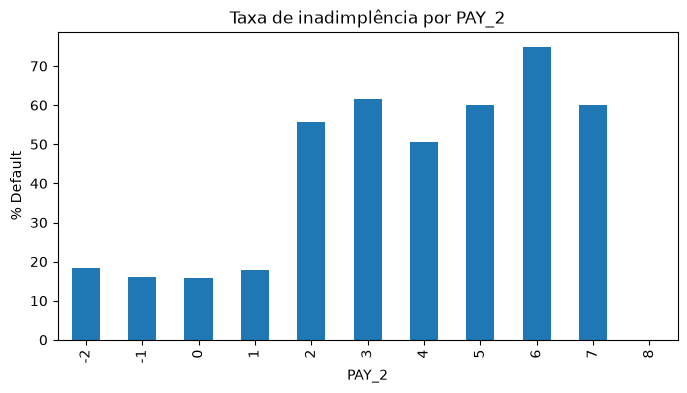

PAY_3
default payment next month      0      1
PAY_3                                   
-2                          81.47  18.53
-1                          84.41  15.59
 0                          82.55  17.45
 1                          75.00  25.00
 2                          48.44  51.56
 3                          42.50  57.50
 4                          42.11  57.89
 5                          42.86  57.14
 6                          39.13  60.87
 7                          18.52  81.48
 8                          33.33  66.67


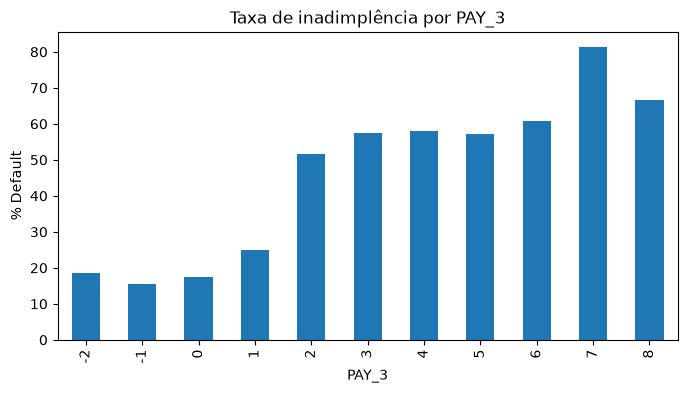

PAY_4
default payment next month      0      1
PAY_4                                   
-2                          80.75  19.25
-1                          84.10  15.90
 0                          81.67  18.33
 1                          50.00  50.00
 2                          47.67  52.33
 3                          38.89  61.11
 4                          33.33  66.67
 5                          48.57  51.43
 6                          60.00  40.00
 7                          17.24  82.76
 8                          50.00  50.00


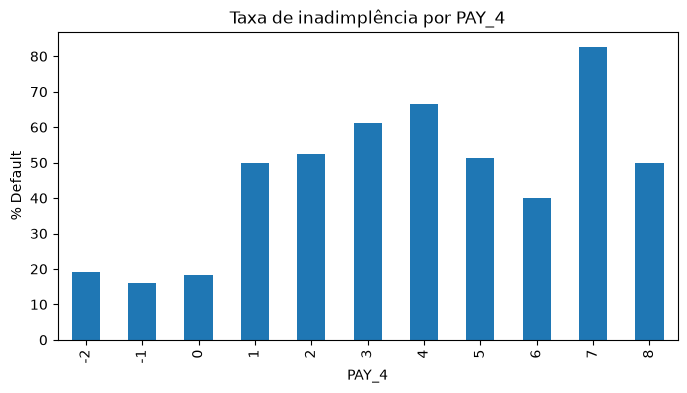

PAY_5
default payment next month      0       1
PAY_5                                    
-2                          80.31   19.69
-1                          83.81   16.19
 0                          81.15   18.85
 2                          45.81   54.19
 3                          36.52   63.48
 4                          39.29   60.71
 5                          41.18   58.82
 6                          25.00   75.00
 7                          17.24   82.76
 8                           0.00  100.00


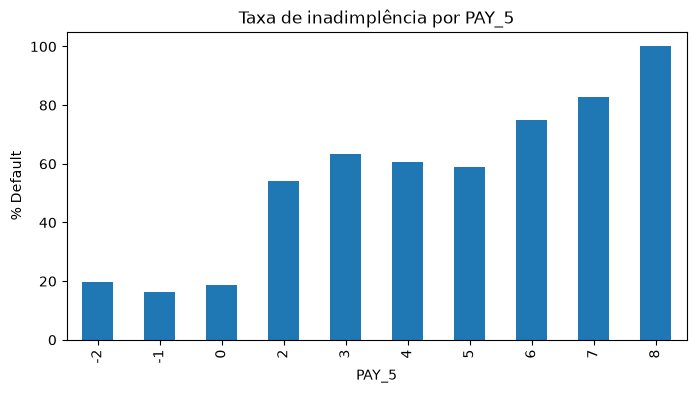

PAY_6
default payment next month      0       1
PAY_6                                    
-2                          79.96   20.04
-1                          83.01   16.99
 0                          81.16   18.84
 2                          49.35   50.65
 3                          35.87   64.13
 4                          36.73   63.27
 5                          46.15   53.85
 6                          26.32   73.68
 7                          17.39   82.61
 8                           0.00  100.00


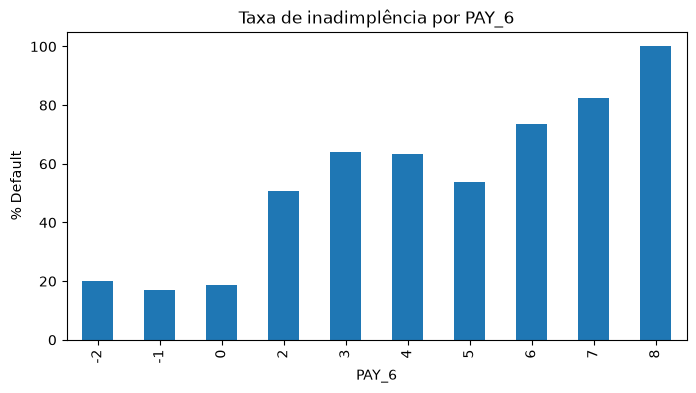

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pointbiserialr

target = "default payment next month"

print("="*60)
print("VARIÁVEL RESPOSTA")
print("="*60)

freq = df[target].value_counts().sort_index()
perc = df[target].value_counts(normalize=True).sort_index()*100

resumo = pd.DataFrame({
    "Frequência": freq,
    "Percentual (%)": perc.round(2)
})

print(resumo)

plt.figure(figsize=(6,4))

plt.bar(
    ["Adimplente","Inadimplente"],
    freq.values
)

plt.title("Distribuição da variável resposta")
plt.ylabel("Quantidade")

plt.show()

numericas = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

for var in numericas:

    print("="*70)
    print(var)
    print("="*70)

    print(df.groupby(target)[var].describe()[[
        "mean",
        "50%",
        "std",
        "min",
        "max"
    ]])

    plt.figure(figsize=(6,4))

    df.boxplot(
        column=var,
        by=target
    )

    plt.title(f"{var} por classe")

    plt.suptitle("")

    plt.xlabel("Default")

    plt.ylabel(var)

    plt.show()

    categoricas = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for var in categoricas:

    print("="*70)
    print(var)
    print("="*70)

    tabela = pd.crosstab(
        df[var],
        df[target],
        normalize="index"
    )*100

    print(tabela.round(2))

    taxa = tabela[1]

    plt.figure(figsize=(8,4))

    taxa.plot(kind="bar")

    plt.ylabel("% Default")

    plt.title(f"Taxa de inadimplência por {var}")

    plt.show()



In [43]:
resultado = []

for var in numericas:

    corr, p = pointbiserialr(
        df[target],
        df[var]
    )

    resultado.append({
        "Variável": var,
        "Correlação": corr,
        "p-valor": p
    })

correlacao_target = (
    pd.DataFrame(resultado)
    .sort_values(
        "Correlação",
        key=lambda x: abs(x),
        ascending=False
    )
)

correlacao_target

print("="*70)
print("VARIÁVEIS MAIS CORRELACIONADAS COM O DEFAULT")
print("="*70)

print(correlacao_target)

VARIÁVEIS MAIS CORRELACIONADAS COM O DEFAULT
     Variável  Correlação        p-valor
0   LIMIT_BAL   -0.153520  1.302244e-157
8    PAY_AMT1   -0.072929   1.146488e-36
9    PAY_AMT2   -0.058579   3.166657e-24
11   PAY_AMT4   -0.056827   6.830942e-23
10   PAY_AMT3   -0.056250   1.841770e-22
12   PAY_AMT5   -0.055124   1.241345e-21
13   PAY_AMT6   -0.053183   3.033589e-20
2   BILL_AMT1   -0.019644   6.673295e-04
3   BILL_AMT2   -0.014193   1.395736e-02
4   BILL_AMT3   -0.014076   1.476998e-02
1         AGE    0.013890   1.613685e-02
5   BILL_AMT4   -0.010156   7.855564e-02
6   BILL_AMT5   -0.006760   2.416344e-01
7   BILL_AMT6   -0.005372   3.521225e-01


ANÁLISE: SEX

Tabela de contingência
default payment next month      0     1
SEX                                    
1                            9015  2873
2                           14349  3763

Taxa de inadimplência
default payment next month  Adimplente (%)  Default (%)
SEX                                                    
1                                    75.83        24.17
2                                    79.22        20.78

Qui-quadrado
Chi² = 47.71
p-valor = 0.0000000000
Cramer's V = 0.040


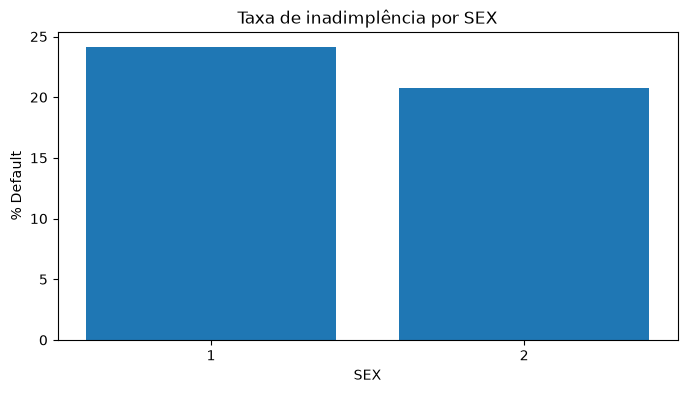

ANÁLISE: EDUCATION

Tabela de contingência
default payment next month      0     1
EDUCATION                              
0                              14     0
1                            8549  2036
2                           10700  3330
3                            3680  1237
4                             116     7
5                             262    18
6                              43     8

Taxa de inadimplência
default payment next month  Adimplente (%)  Default (%)
EDUCATION                                              
0                                   100.00         0.00
1                                    80.77        19.23
2                                    76.27        23.73
3                                    74.84        25.16
4                                    94.31         5.69
5                                    93.57         6.43
6                                    84.31        15.69

Qui-quadrado
Chi² = 163.22
p-valor = 0.0000000000
Cramer's V = 0.074


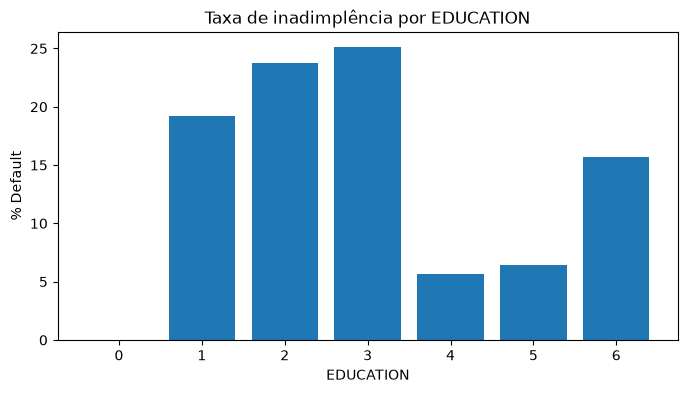

ANÁLISE: MARRIAGE

Tabela de contingência
default payment next month      0     1
MARRIAGE                               
0                              49     5
1                           10453  3206
2                           12623  3341
3                             239    84

Taxa de inadimplência
default payment next month  Adimplente (%)  Default (%)
MARRIAGE                                               
0                                    90.74         9.26
1                                    76.53        23.47
2                                    79.07        20.93
3                                    73.99        26.01

Qui-quadrado
Chi² = 35.66
p-valor = 0.0000000883
Cramer's V = 0.034


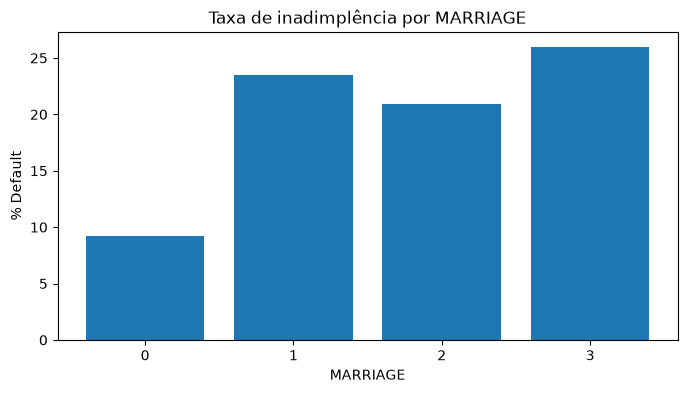

ANÁLISE: PAY_0

Tabela de contingência
default payment next month      0     1
PAY_0                                  
-2                           2394   365
-1                           4732   954
 0                          12849  1888
 1                           2436  1252
 2                            823  1844
 3                             78   244
 4                             24    52
 5                             13    13
 6                              5     6
 7                              2     7
 8                              8    11

Taxa de inadimplência
default payment next month  Adimplente (%)  Default (%)
PAY_0                                                  
-2                                   86.77        13.23
-1                                   83.22        16.78
 0                                   87.19        12.81
 1                                   66.05        33.95
 2                                   30.86        69.14
 3                        

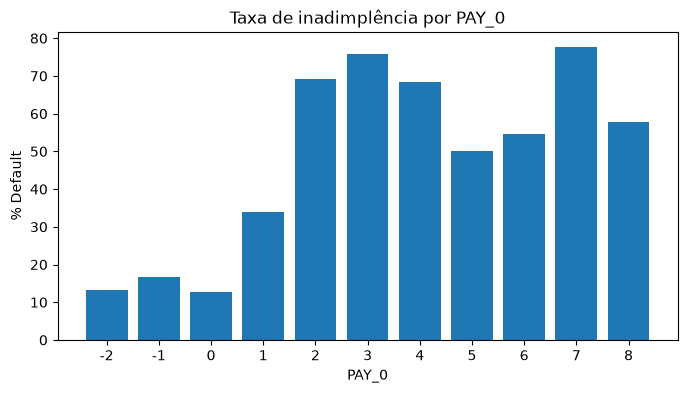

ANÁLISE: PAY_2

Tabela de contingência
default payment next month      0     1
PAY_2                                  
-2                           3091   691
-1                           5084   966
 0                          13227  2503
 1                             23     5
 2                           1743  2184
 3                            125   201
 4                             49    50
 5                             10    15
 6                              3     9
 7                              8    12
 8                              1     0

Taxa de inadimplência
default payment next month  Adimplente (%)  Default (%)
PAY_2                                                  
-2                                   81.73        18.27
-1                                   84.03        15.97
 0                                   84.09        15.91
 1                                   82.14        17.86
 2                                   44.39        55.61
 3                        

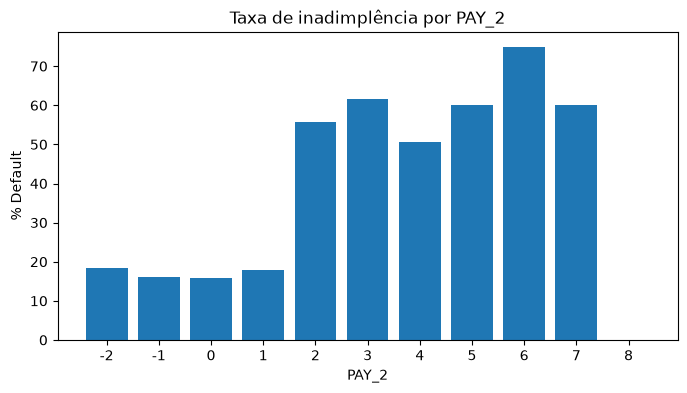

ANÁLISE: PAY_3

Tabela de contingência
default payment next month      0     1
PAY_3                                  
-2                           3328   757
-1                           5012   926
 0                          13013  2751
 1                              3     1
 2                           1850  1969
 3                            102   138
 4                             32    44
 5                              9    12
 6                              9    14
 7                              5    22
 8                              1     2

Taxa de inadimplência
default payment next month  Adimplente (%)  Default (%)
PAY_3                                                  
-2                                   81.47        18.53
-1                                   84.41        15.59
 0                                   82.55        17.45
 1                                   75.00        25.00
 2                                   48.44        51.56
 3                        

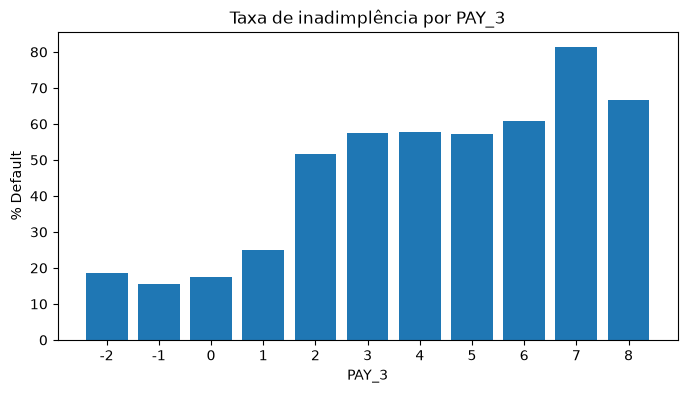

ANÁLISE: PAY_4

Tabela de contingência
default payment next month      0     1
PAY_4                                  
-2                           3511   837
-1                           4783   904
 0                          13439  3016
 1                              1     1
 2                           1506  1653
 3                             70   110
 4                             23    46
 5                             17    18
 6                              3     2
 7                             10    48
 8                              1     1

Taxa de inadimplência
default payment next month  Adimplente (%)  Default (%)
PAY_4                                                  
-2                                   80.75        19.25
-1                                   84.10        15.90
 0                                   81.67        18.33
 1                                   50.00        50.00
 2                                   47.67        52.33
 3                        

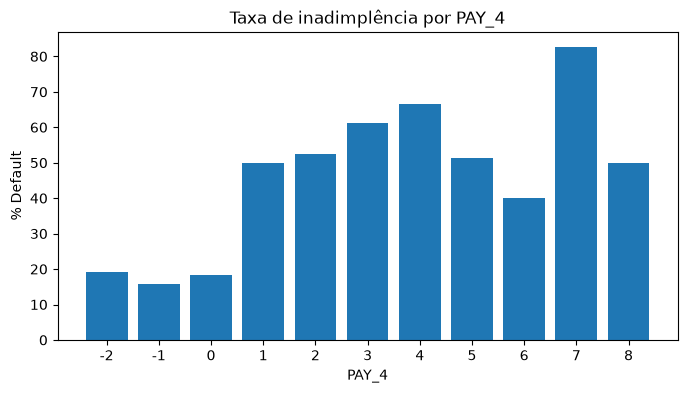

ANÁLISE: PAY_5

Tabela de contingência
default payment next month      0     1
PAY_5                                  
-2                           3651   895
-1                           4642   897
 0                          13752  3195
 2                           1203  1423
 3                             65   113
 4                             33    51
 5                              7    10
 6                              1     3
 7                             10    48
 8                              0     1

Taxa de inadimplência
default payment next month  Adimplente (%)  Default (%)
PAY_5                                                  
-2                                   80.31        19.69
-1                                   83.81        16.19
 0                                   81.15        18.85
 2                                   45.81        54.19
 3                                   36.52        63.48
 4                                   39.29        60.71
 5        

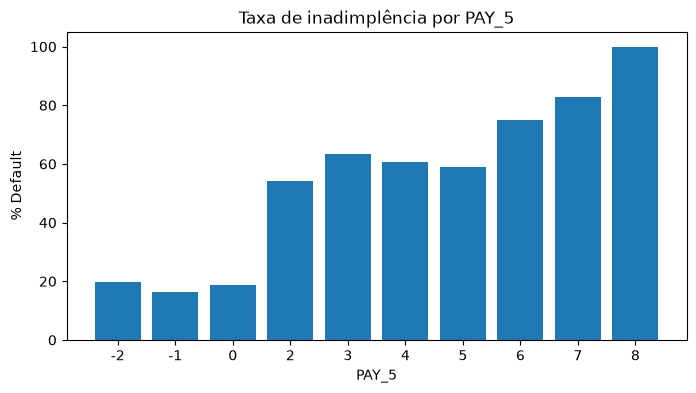

ANÁLISE: PAY_6

Tabela de contingência
default payment next month      0     1
PAY_6                                  
-2                           3914   981
-1                           4765   975
 0                          13217  3069
 2                           1365  1401
 3                             66   118
 4                             18    31
 5                              6     7
 6                              5    14
 7                              8    38
 8                              0     2

Taxa de inadimplência
default payment next month  Adimplente (%)  Default (%)
PAY_6                                                  
-2                                   79.96        20.04
-1                                   83.01        16.99
 0                                   81.16        18.84
 2                                   49.35        50.65
 3                                   35.87        64.13
 4                                   36.73        63.27
 5        

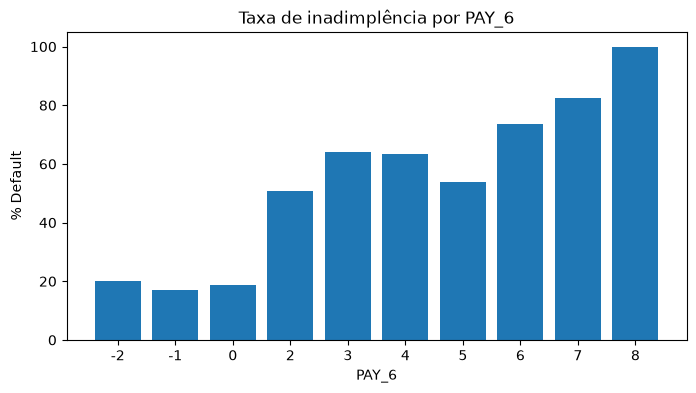



RESUMO DAS ASSOCIAÇÕES
    Variável  Qui-quadrado  p-valor  Cramer's V
3      PAY_0      5365.965      0.0       0.423
4      PAY_2      3474.467      0.0       0.340
5      PAY_3      2622.462      0.0       0.296
6      PAY_4      2341.470      0.0       0.279
7      PAY_5      2197.695      0.0       0.271
8      PAY_6      1886.835      0.0       0.251
1  EDUCATION       163.217      0.0       0.074
0        SEX        47.709      0.0       0.040
2   MARRIAGE        35.662      0.0       0.034


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

target = "default payment next month"

categoricas = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

resumo = []

for var in categoricas:

    print("="*70)
    print(f"ANÁLISE: {var}")
    print("="*70)

    ######################################################
    # Frequências
    ######################################################

    tabela = pd.crosstab(df[var], df[target])

    print("\nTabela de contingência")
    print(tabela)

    ######################################################
    # Taxa de default
    ######################################################

    taxa = pd.crosstab(
        df[var],
        df[target],
        normalize="index"
    )*100

    taxa = taxa.rename(
        columns={
            0:"Adimplente (%)",
            1:"Default (%)"
        }
    )

    print("\nTaxa de inadimplência")
    print(taxa.round(2))

    ######################################################
    # Qui-quadrado
    ######################################################

    chi2, p, gl, exp = chi2_contingency(tabela)

    print("\nQui-quadrado")

    print(f"Chi² = {chi2:.2f}")
    print(f"p-valor = {p:.10f}")

    ######################################################
    # Cramer's V
    ######################################################

    n = tabela.sum().sum()

    phi2 = chi2/n

    r, k = tabela.shape

    cramers_v = np.sqrt(phi2/(min(r-1,k-1)))

    print(f"Cramer's V = {cramers_v:.3f}")

    ######################################################
    # Gráfico
    ######################################################

    plt.figure(figsize=(8,4))

    plt.bar(
        taxa.index.astype(str),
        taxa["Default (%)"]
    )

    plt.ylabel("% Default")

    plt.xlabel(var)

    plt.title(f"Taxa de inadimplência por {var}")

    plt.show()

    ######################################################
    # Salvar resumo
    ######################################################

    resumo.append({
        "Variável":var,
        "Qui-quadrado":chi2,
        "p-valor":p,
        "Cramer's V":cramers_v
    })

resumo = (
    pd.DataFrame(resumo)
    .sort_values("Cramer's V", ascending=False)
)

print("\n")
print("="*80)
print("RESUMO DAS ASSOCIAÇÕES")
print("="*80)

print(resumo.round(3))